# Xformers Time Series Library - Interactive Demo

This notebook provides a step-by-step demonstration of the **Xformers Time Series Library**. 
We will show how to use the modular components to: 
1. Prepare data (`DataPreprocessor`, `TimeSeriesDataset`)
2. Build a Transformer model (`XformersTimeSeriesModel`)
3. Train and Evaluate the model (`train_model`, `evaluate_model`)

We will use **synthetic data** (a noisy sine wave) to demonstrate that the tool is generic and can work on any time-series problem, not just stock prices.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from xformers_timeseries_utils import TimeSeriesDataset, XformersTimeSeriesModel, DataPreprocessor, train_model, evaluate_model

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Xformers components initialized. Using fallback: True
Using device: cpu


## 1. Data Generation
First, let's create a synthetic dataset. We'll generate a sine wave with some added noise.

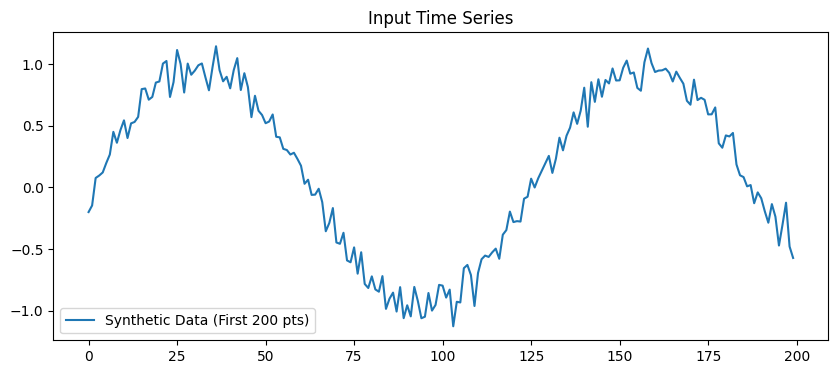

In [2]:
# Generate 1000 points of a sine wave
t = np.linspace(0, 50, 1000)
data = np.sin(t) + np.random.normal(0, 0.1, 1000)

# Wrap in a DataFrame as expected by the Preprocessor
df = pd.DataFrame(data, columns=['Value'])

plt.figure(figsize=(10, 4))
plt.plot(df['Value'][:200], label='Synthetic Data (First 200 pts)')
plt.title("Input Time Series")
plt.legend()
plt.show()

## 2. Preprocessing
We use `DataPreprocessor` to scale the data (0-1 range) and split it into training and testing sets. 
Note: `fit_transform` returns Datasets, so we wrap them in DataLoaders for batching.

In [3]:
SEQ_LEN = 30  # Lookback window
BATCH_SIZE = 32

processor = DataPreprocessor(seq_len=SEQ_LEN, train_split=0.8)
train_dataset, test_dataset, scaler = processor.fit_transform(df, ['Value'])

# Wrap in DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"p.s. fit_transform returns: {type(train_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Testing batches: {len(test_loader)}")

p.s. fit_transform returns: <class 'xformers_timeseries_utils.TimeSeriesDataset'>
Training batches: 25
Testing batches: 6


## 3. Model Initialization
We instantiate `XformersTimeSeriesModel`.

In [4]:
model = XformersTimeSeriesModel(
    input_dim=1,      # Only 1 feature ('Value')
    d_model=32,       # Embedding dimension
    nhead=2,          # Number of heads
    num_layers=1,     # Encoder layers
    dropout=0.1
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

XformersTimeSeriesModel(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (attn): MultiHeadDispatch(
    (mha): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
    )
  )
  (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (ff): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=32, bias=True)
  )
  (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (dropout2): Dropout(p=0.1, inplace=False)
  (decoder): Linear(in_features=32, out_features=1, bias=True)
)


## 4. Training Loop
We use the modular `train_model` function.

Epoch 1/5, Loss: 0.185646
Epoch 2/5, Loss: 0.032093


Epoch 3/5, Loss: 0.013598
Epoch 4/5, Loss: 0.009650


Epoch 5/5, Loss: 0.008293


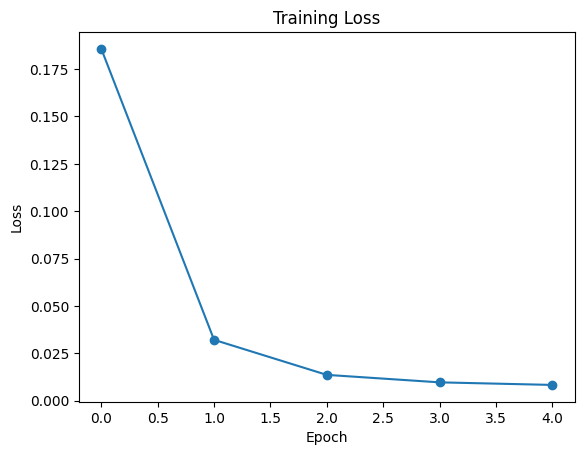

In [5]:
loss_history = train_model(model, train_loader, criterion, optimizer, device, epochs=5)

plt.plot(loss_history, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 5. Evaluation
We generate predictions on the test set using `evaluate_model` and visualize the results.

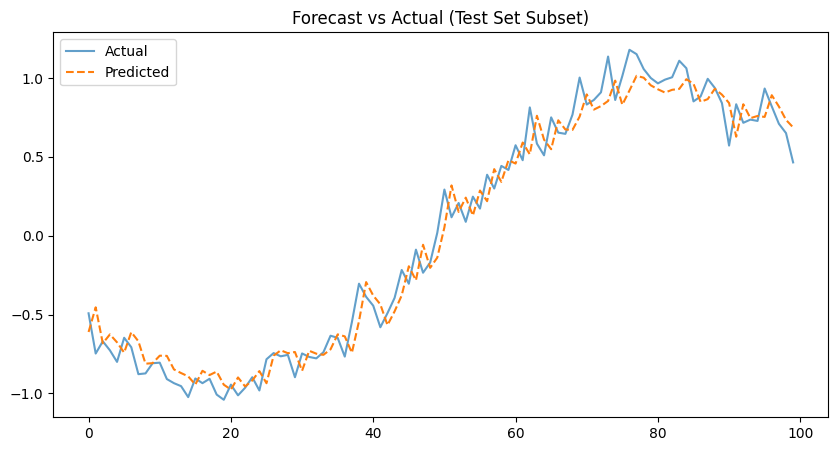

In [6]:
preds, actuals = evaluate_model(model, test_loader, device)

# Inverse transform to get back to original scale
preds_unscaled = scaler.inverse_transform(preds)
actuals_unscaled = scaler.inverse_transform(actuals)

plt.figure(figsize=(10, 5))
plt.plot(actuals_unscaled[:100], label='Actual', alpha=0.7)
plt.plot(preds_unscaled[:100], label='Predicted', linestyle='--')
plt.title("Forecast vs Actual (Test Set Subset)")
plt.legend()
plt.show()